# PlanetScope Master Match Summary

This notebook summarizes [`fetch/PS/master_match.json`](/workspace/fetch/PS/master_match.json): match counts by event and chip locations colored by match status on an OpenStreetMap basemap.


In [1]:
from pathlib import Path
import json

import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

REPO_ROOT = Path('/workspace')
MASTER_MATCH_FP = REPO_ROOT / 'fetch' / 'PS' / 'master_match.json'
STAC_CATALOG_FP = REPO_ROOT / 'stac_catalog.geojson'

COLOR_D = {
    'nomatch': '#d62728',
    'match': '#2ca02c',
}


## Load Results


In [2]:
with MASTER_MATCH_FP.open() as f:
    master_d = json.load(f)

match_df = pd.DataFrame(master_d['records']).copy()
match_df['matched'] = match_df['current_workflow_matched'].fillna(False).astype(bool)
match_df['match_status'] = match_df['matched'].map({True: 'match', False: 'nomatch'})
match_df['event'] = match_df['event'].astype(str)
match_df['chip_id'] = match_df['chip_id'].astype(str)

assert master_d['record_count'] == len(match_df), (master_d['record_count'], len(match_df))
display(match_df[['event', 'chip_id', 'item_id', 'match_status', 'selection_reason', 'timedelta_hours']].head())


,event,chip_id,item_id,match_status,selection_reason,timedelta_hours
0,US-Alabama,NAL_14_30,20190525_161148_100a,match,current_matched,0.030
1,US-Alabama,NAL_16_10,20190527_164551_79_106a,nomatch,best_unmatched_attempt,48.598
2,US-Alabama,NAL_27_45,20190525_160945_100e,match,current_matched,0.004
3,US-Alabama,NAL_31_29,20190525_160937_100e,match,current_matched,0.006
4,US-Alabama,NAL_92_47,20190525_160212_1024,match,current_matched,0.130


## Match Counts By Event


In [3]:
event_status_df = (
    match_df
    .groupby(['event', 'match_status'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['nomatch', 'match'], fill_value=0)
    .sort_index()
)
event_status_df['total'] = event_status_df.sum(axis=1)
display(event_status_df)


match_status,nomatch,match,total
event,,,
US-Alabama,1,4,5
US-Arkansas,0,1,1
US-Carolina,2,2,4
US-Dakota,3,5,8
US-Kansas,3,0,3
US-Nebraska,0,5,5
US-Oklahoma,0,5,5
US-Texas,0,2,2


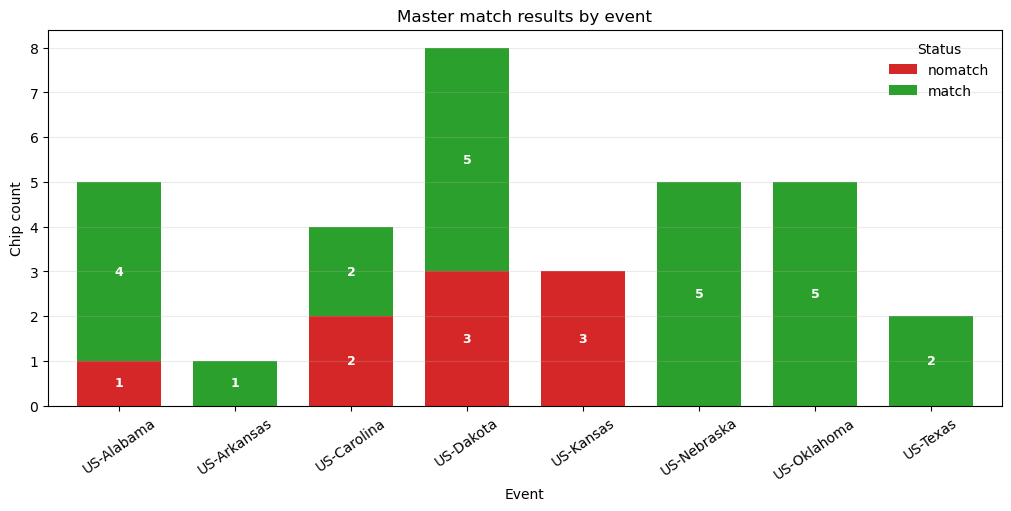

In [4]:
plot_df = event_status_df[['nomatch', 'match']]
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
plot_df.plot(
    kind='bar',
    stacked=True,
    color=[COLOR_D['nomatch'], COLOR_D['match']],
    width=0.72,
    ax=ax,
)

ax.set_title('Master match results by event')
ax.set_xlabel('Event')
ax.set_ylabel('Chip count')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='Status', frameon=False)
ax.grid(axis='y', alpha=0.25)

for event_i, (_, row_s) in enumerate(plot_df.iterrows()):
    bottom = 0
    for status in ['nomatch', 'match']:
        count = int(row_s[status])
        if count > 0:
            ax.text(event_i, bottom + count / 2, str(count), ha='center', va='center', color='white', fontsize=9, fontweight='bold')
        bottom += count

plt.show()


## Chip Map


In [5]:
catalog_gdf = gpd.read_file(STAC_CATALOG_FP)[['Event', 'Chip_ID', 'geometry']].copy()
catalog_gdf['Event'] = catalog_gdf['Event'].astype(str)
catalog_gdf['Chip_ID'] = catalog_gdf['Chip_ID'].astype(str)

chip_gdf = catalog_gdf.merge(
    match_df,
    left_on=['Event', 'Chip_ID'],
    right_on=['event', 'chip_id'],
    how='inner',
    validate='one_to_one',
)
assert len(chip_gdf) == len(match_df), (len(chip_gdf), len(match_df))

chip_point_gdf = chip_gdf.to_crs(epsg=3857)
chip_point_gdf['geometry'] = chip_point_gdf.geometry.centroid
chip_point_gdf = chip_point_gdf.set_geometry('geometry')

display(chip_point_gdf[['event', 'chip_id', 'match_status', 'item_id', 'timedelta_hours']].head())


,event,chip_id,match_status,item_id,timedelta_hours
0,US-Alabama,NAL_14_30,match,20190525_161148_100a,0.030
1,US-Alabama,NAL_16_10,nomatch,20190527_164551_79_106a,48.598
2,US-Alabama,NAL_27_45,match,20190525_160945_100e,0.004
3,US-Alabama,NAL_31_29,match,20190525_160937_100e,0.006
4,US-Alabama,NAL_92_47,match,20190525_160212_1024,0.130


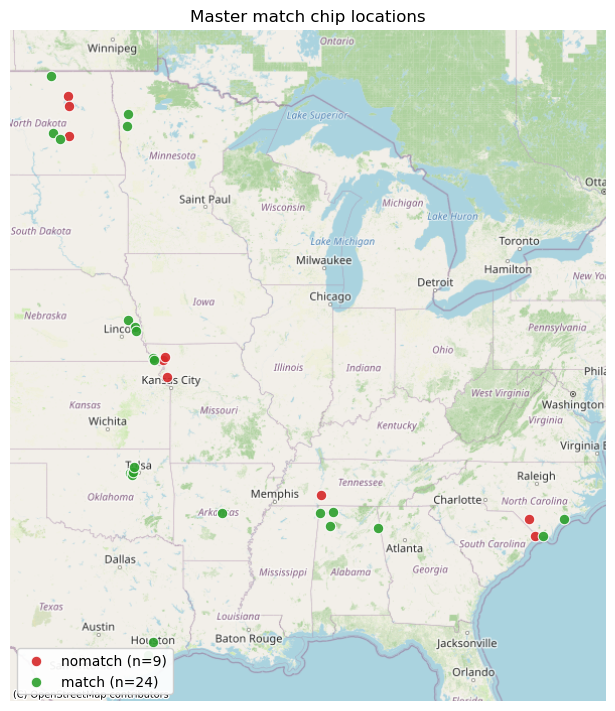

In [6]:
fig, ax = plt.subplots(figsize=(11, 7), constrained_layout=True)

xmin, ymin, xmax, ymax = chip_point_gdf.total_bounds
x_pad = max((xmax - xmin) * 0.08, 50_000)
y_pad = max((ymax - ymin) * 0.08, 50_000)
ax.set_xlim(xmin - x_pad, xmax + x_pad)
ax.set_ylim(ymin - y_pad, ymax + y_pad)

for status in ['nomatch', 'match']:
    status_gdf = chip_point_gdf.loc[chip_point_gdf['match_status'] == status]
    status_gdf.plot(
        ax=ax,
        color=COLOR_D[status],
        markersize=58,
        marker='o',
        edgecolor='white',
        linewidth=0.8,
        alpha=0.9,
        label=f"{status} (n={len(status_gdf)})",
        zorder=3,
    )

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=chip_point_gdf.crs,
    attribution_size=7,
    zorder=1,
)

ax.set_title('Master match chip locations')
ax.set_axis_off()
ax.legend(loc='lower left', frameon=True, framealpha=0.92)
plt.show()
